# Model Von_heijne
## 1. Environment setup and path configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, f1_score, matthews_corrcoef, accuracy_score, confusion_matrix

# Set project root directory
PROJECT_ROOT = r"C:\Users\b1795\Desktop\Laboratory2_SP"

# Define subdirectories
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data_raw")
DATA_PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data_processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
CV_DIR = os.path.join(DATA_PROCESSED_DIR, "cv_folds")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Environment setup completed.")
print(f"Data directory: {DATA_PROCESSED_DIR}")

Environment setup completed.
Data directory: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed


## 2. Load sequence data (FASTA)

In [2]:
def load_fasta_dict(fasta_path):
    """Read a FASTA file and return a {Accession: Sequence} dictionary"""
    seqs = {}
    header = None
    seq = []
    if not os.path.exists(fasta_path):
        raise FileNotFoundError(f"FASTA file not found: {fasta_path}")
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header:
                    seqs[header] = "".join(seq)
                header = line[1:].split()[0] # Extract accession
                seq = []
            else:
                seq.append(line)
        if header:
            seqs[header] = "".join(seq)
    return seqs

print("Loading sequence data:")
# Load all sequences from Positive and Negative datasets
seq_dict_pos = load_fasta_dict(os.path.join(DATA_RAW_DIR, "positive.fasta"))
seq_dict_neg = load_fasta_dict(os.path.join(DATA_RAW_DIR, "negative.fasta"))

# Merge into a single dictionary for convenient lookup
seq_dict_all = {**seq_dict_pos, **seq_dict_neg} 
print(f"Sequence loading completed, total {len(seq_dict_all)} sequences.")

Loading sequence data:
Sequence loading completed, total 23550 sequences.


## 3. Define model class (VonHeijnePSWM)

In [4]:
class VonHeijnePSWM:
    def __init__(self, window_left=13, window_right=2):
        # Window definition: [-13, +2]
        self.window_left = window_left
        self.window_right = window_right
        self.window_len = window_left + window_right # Total length: 15
        
        self.aa_order = list("ACDEFGHIKLMNPQRSTVWY")
        self.aa_to_idx = {aa: i for i, aa in enumerate(self.aa_order)}
        self.pswm = None # Weight matrix
        
        # Background frequencies (SwissProt 2025_04)
        self.bg_freqs = {
            'A': 8.25, 'R': 5.52, 'N': 4.06, 'D': 5.46, 'C': 1.38,
            'Q': 3.93, 'E': 6.71, 'G': 7.07, 'H': 2.27, 'I': 5.90,
            'L': 9.64, 'K': 5.79, 'M': 2.41, 'F': 3.86, 'P': 4.74,
            'S': 6.65, 'T': 5.36, 'W': 1.10, 'Y': 2.92, 'V': 6.85
        }
        # Convert to probability array
        self.bg_probs = np.array([self.bg_freqs[aa]/100.0 for aa in self.aa_order])

    def fit(self, df_train_pos, seq_dict):
        """Training step: compute the PSWM matrix"""
        # Initialize count matrix (add-one smoothing / pseudocounts)
        counts = np.ones((20, self.window_len), dtype=float)
        
        n_seqs = 0
        for _, row in df_train_pos.iterrows():
            acc = row['accession']
            if acc not in seq_dict: continue
            
            seq = str(seq_dict[acc])
            site = int(row['sp_cleavage_site']) # 1-based cleavage position
            
            # Compute window slice
            start_idx = site - self.window_left
            end_idx = site + self.window_right
            
            if start_idx < 0 or end_idx > len(seq): continue
            
            window = seq[start_idx:end_idx]
            
            if len(window) == self.window_len:
                n_seqs += 1
                for pos, aa in enumerate(window):
                    if aa in self.aa_to_idx:
                        row_idx = self.aa_to_idx[aa]
                        counts[row_idx, pos] += 1
        
        # Compute frequency matrix P_kj
        col_sums = counts.sum(axis=0)
        P_kj = counts / col_sums
        
        # Compute weight matrix w = log(P_kj / b_k)
        self.pswm = np.log(P_kj / self.bg_probs[:, np.newaxis])
        
        print(f"Model training completed using {n_seqs} positive sequences.")
        return self

    def predict_score(self, sequence):
        """Prediction step: scan the first 90 amino acids of the sequence and return the maximum score"""
        target_seq = sequence[:90] # Slide 13 requires scanning the N-terminus
        L = len(target_seq)
        
        if L < self.window_len:
            return -999.0 
            
        max_score = -999.0
        
        # Sliding window scan
        for i in range(L - self.window_len + 1):
            window = target_seq[i : i + self.window_len]
            current_score = 0.0
            
            for pos, aa in enumerate(window):
                if aa in self.aa_to_idx:
                    row_idx = self.aa_to_idx[aa]
                    current_score += self.pswm[row_idx, pos]
                else:
                    current_score -= 10 # Penalize unknown amino acids
            
            if current_score > max_score:
                max_score = current_score
                
        return max_score

print("Model class definition completed.")

Model class definition completed.


## 4. 5-fold cross-validation 

In [5]:
print("Start 5-fold cross-validation:")

# Load training set with fold information
df_train_all = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "training_with_fold_info.tsv"), sep="\t")

best_thresholds = [] # Store the best threshold for each fold
fold_metrics = []

for fold_k in range(1, 6):
    print(f"\nFold {fold_k}")
    
    # Split into Train / Validation / Test sets
    # Logic: Fold k is Test, (k%5)+1 is Validation, remaining three folds are Train
    test_fold_id = fold_k
    val_fold_id = (fold_k % 5) + 1
    train_fold_ids = [f for f in [1,2,3,4,5] if f != test_fold_id and f != val_fold_id]
    
    df_cv_train = df_train_all[df_train_all['fold'].isin(train_fold_ids)]
    df_cv_val = df_train_all[df_train_all['fold'] == val_fold_id]
    df_cv_test = df_train_all[df_train_all['fold'] == test_fold_id]
    
    # Train the model (using only Positive samples from the training set)
    df_cv_train_pos = df_cv_train[df_cv_train['label'] == 1]
    model = VonHeijnePSWM()
    model.fit(df_cv_train_pos, seq_dict_all)
    
    # Validation (find the optimal threshold on the Validation set)
    val_scores = []
    val_labels = df_cv_val['label'].values
    for acc in df_cv_val['accession']:
        seq = str(seq_dict_all.get(acc, ""))
        val_scores.append(model.predict_score(seq))
    
    # Use the Precision-Recall curve to find the threshold that maximizes F1
    precisions, recalls, thresholds = precision_recall_curve(val_labels, val_scores)
    # Compute F1 score
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_th = thresholds[best_idx]
    best_thresholds.append(best_th)
    
    print(f"Best threshold (Validation): {best_th:.2f} (Max F1: {f1_scores[best_idx]:.3f})")
    
    # Testing (evaluate on the Test set)
    test_scores = []
    test_labels = df_cv_test['label'].values
    for acc in df_cv_test['accession']:
        seq = str(seq_dict_all.get(acc, ""))
        test_scores.append(model.predict_score(seq))
        
    # Classify using the previously determined best threshold
    test_preds = [1 if s >= best_th else 0 for s in test_scores]
    
    acc = accuracy_score(test_labels, test_preds)
    mcc = matthews_corrcoef(test_labels, test_preds)
    
    print(f"Test set performance: ACC={acc:.3f}, MCC={mcc:.3f}")

# Compute average threshold for the final model
avg_threshold = np.mean(best_thresholds)
print(f"\nCross-validation completed. Average optimal threshold: {avg_threshold:.3f}")

Start 5-fold cross-validation:

Fold 1
Model training completed using 1408 positive sequences.
Best threshold (Validation): 6.32 (Max F1: 0.729)
Test set performance: ACC=0.930, MCC=0.700

Fold 2
Model training completed using 1408 positive sequences.
Best threshold (Validation): 5.88 (Max F1: 0.739)
Test set performance: ACC=0.924, MCC=0.680

Fold 3
Model training completed using 1409 positive sequences.
Best threshold (Validation): 5.77 (Max F1: 0.765)
Test set performance: ACC=0.923, MCC=0.688

Fold 4
Model training completed using 1410 positive sequences.
Best threshold (Validation): 6.07 (Max F1: 0.779)
Test set performance: ACC=0.936, MCC=0.729

Fold 5
Model training completed using 1409 positive sequences.
Best threshold (Validation): 6.23 (Max F1: 0.747)
Test set performance: ACC=0.942, MCC=0.742

Cross-validation completed. Average optimal threshold: 6.056


## 5. Final model training

In [6]:
print("Training the final model: ")
# Extract all Positive samples from the training set
df_final_train_pos = df_train_all[df_train_all['label'] == 1]
final_model = VonHeijnePSWM()
final_model.fit(df_final_train_pos, seq_dict_all)
print("Final model is ready.")

Training the final model: 
Model training completed using 2348 positive sequences.
Final model is ready.


## 6. Benchmark evaluation

In [7]:
print("Benchmark evaluation")

# Load benchmark data
df_bench_pos = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "benchmark_positive.tsv"), sep="\t")
df_bench_neg = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "benchmark_negative.tsv"), sep="\t")

# Merge datasets and assign labels
df_bench_pos['label'] = 1
df_bench_neg['label'] = 0
df_benchmark = pd.concat([df_bench_pos, df_bench_neg], ignore_index=True)

# Predict scores
bench_scores = []
bench_labels = df_benchmark['label'].values
for acc in df_benchmark['accession']:
    seq = str(seq_dict_all.get(acc, ""))
    bench_scores.append(final_model.predict_score(seq))

# Classify using the average threshold obtained from cross-validation
bench_preds = [1 if s >= avg_threshold else 0 for s in bench_scores]

# Compute evaluation metrics
final_acc = accuracy_score(bench_labels, bench_preds)
final_mcc = matthews_corrcoef(bench_labels, bench_preds)
final_cm = confusion_matrix(bench_labels, bench_preds)

print(f"Threshold used: {avg_threshold:.3f}")
print(f"Final accuracy (Accuracy): {final_acc:.3f}")
print(f"Matthews correlation coefficient (MCC):  {final_mcc:.3f}")
print("Confusion matrix:")
print(final_cm)

Benchmark evaluation
Threshold used: 6.056
Final accuracy (Accuracy): 0.928
Matthews correlation coefficient (MCC):  0.692
Confusion matrix:
[[3906  217]
 [ 124  463]]


## 7. Visualize weight matrix

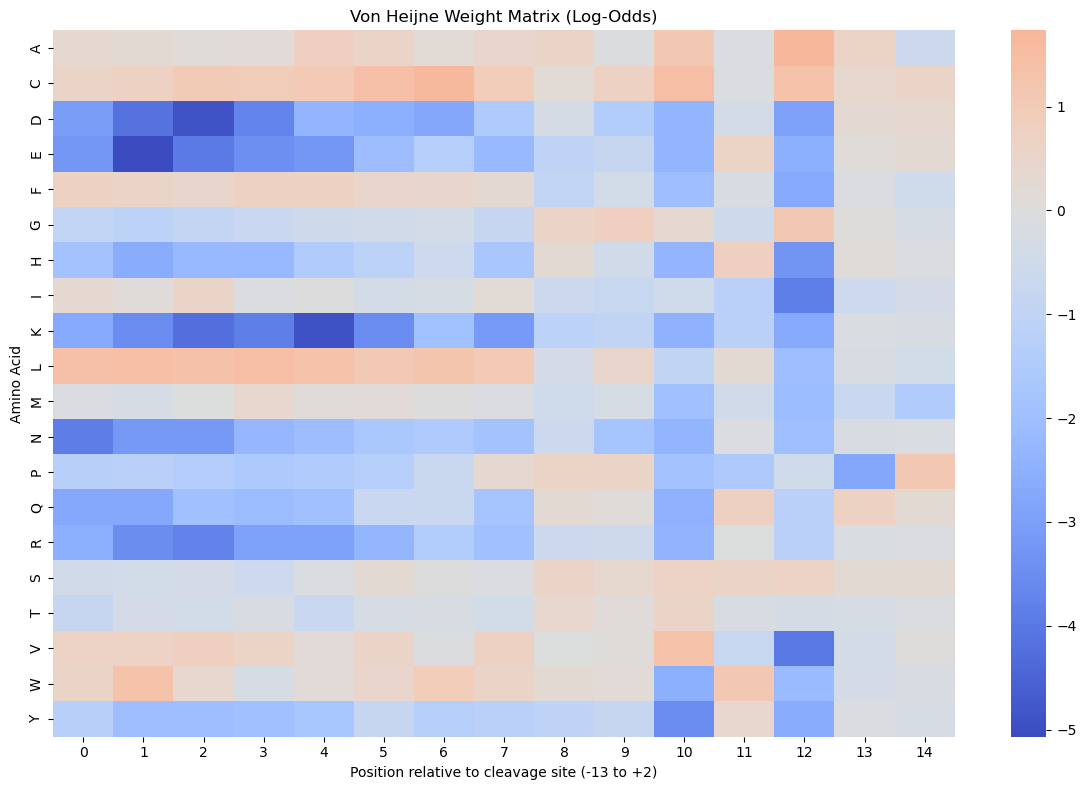

PSWM heatmap saved to: C:\Users\b1795\Desktop\Laboratory2_SP\figures\von_heijne_pswm_heatmap.png

Von_heijne completed.


In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(final_model.pswm, yticklabels=final_model.aa_order, cmap="coolwarm", center=0)

plt.title("Von Heijne Weight Matrix (Log-Odds)")
plt.xlabel("Position relative to cleavage site (-13 to +2)")
plt.ylabel("Amino Acid")

# Save figure
out_path = os.path.join(FIGURES_DIR, "von_heijne_pswm_heatmap.png")
plt.tight_layout()
plt.savefig(out_path, dpi=300)
plt.show()
print(f"PSWM heatmap saved to: {out_path}")

print("\nVon_heijne completed.")